# Module 3.03 - Statistical Hypothesis testing

Another important application of the *central limit theorem* is the concept of **statistical hypothesis testing**. This is a method used to check assumptions about a population based on a sample of observations. In this module, we introduce the concept of a hypothesis test, and we will learn how to perform a one-sample $z$-test and a one-sample $t$-test for the mean.

## Learning goals

By the end of this module, you should be able to:

- Understand the definitions and terminology (indicated with 💡) used in this notebook
- Know the consecutive steps in the procedure of a hypothesis test
- Perform a one-sample z-test for the mean
- Perform a one-sample t-test for the mean
- Determine the appropriate test to use based on the data and assumptions


In [1]:
# Importing the necessary packages
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import random
import math

import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation

## Statistical Hypothesis Testing

### Definitions

- 💡**Hypothesis Test** = A procedure for verifying a hypothesis about the value of a population parameter.
- 💡**Hypothesis** = A statement or conjecture regarding the numeric value of a population parameter.
- The 💡**null Hypothesis** $H_0$ = an assumption about a population parameter that we want to test. The procedure of the test is based on the assumption that the null hypothesis is true. If we then encounter a contradiction, the null hypothesis is rejected and the alternative hypothesis is accepted.
- The 💡**alternative Hypothesis** ($H_1$) = the negation of the null hypothesis. It represents the conclusion of the test if the null hypothesis is unlikely to be true.
- 💡**Critical region** or **rejection region** = The set of all possible values for the test statistic for which we will reject the null hypothesis.
- 💡**Acceptance region** = The set of all possible values for the test statistic that support the null hypothesis.  
- 💡**Critical value** $g$ = Boundary of the critical region  
- 💡**Significance Level** $\alpha$ = The probability of rejecting the null hypothesis $H_0$ when it is actually true.
- 💡**Probability value** or $p$-value = The probability of obtaining a test statistic as extreme as, or more extreme than, the observed value, assuming the null hypothesis is true.

The principle of **hypothesis testing** is to calculate how likely it is to observe the **test statistic** (the statistic calculated from the observations in the sample) if you assume that the null hypothesis $H_0$ is true. If the probability of observing the test statistic is very low, i.e. if the test statistic lies in the most extreme part of the probability distribution (called the **critical region**) you conclude that the null hypothesis is unlikely to be true and you reject it in favour of the alternative hypothesis $H_1$.

All other values lie in the **acceptance region** of the test. The probability of this happening when $H_0$ is actually true is called the size of the test. 5% is often used as the common default size.

Take care in the language that you use!

- If you accept $H_0$, never say that this is because the evidence supports it. You can only conclude there is no significant evidence in the sample *against* $H_0$.
- If you reject $H_0$, say that there is evidence in the sample that the null hypothesis is not true.

All statistical hypothesis tests follow the same 💡**testing procedure**:

1. Formulate both *hypotheses* ($H_0$ and $𝐻_1$)
2. Determine the *significance level* ($\alpha$)
3. Calculate the *test statistic* from the sample
4. Determine the *critical region* or the *probability value*
5. Draw *conclusions* (reject or don't reject $H_0$)


## The z-test

The $z$-test is used to confirm or refute an assumption about the (unknown) *population mean*, based on a sufficiently large random sample.

### Example: the right-tailed $z$-test

Jars of jam are filled by a machine. It has been found that the quantity of jam in a jar is normally distributed and has mean $\mu = 351.2$ g, with standard deviation $\sigma = 4.1$ g. It is believed that the settings of the mean amount on the machine might have been altered accidentally and that the machine is now filling jars with *more* jam. Assume that the standard deviation has not been altered.

To test this, a random sample of $n = 40$ jars is taken and the mean quantity per jar is calculated. The mean quantity per jar is found to be $\bar{x} = 352.8$ g.

This sample meets the conditions where the *central limit theorem* applies, so we know that the probability distribution of the sample mean is a normal distribution with mean $\mu$ and standard deviation $\sigma / \sqrt{n}$, where $n$ is the sample size (or $M \sim Nor(\mu, \sigma/\sqrt{n})$).

Let's first plot the situation:

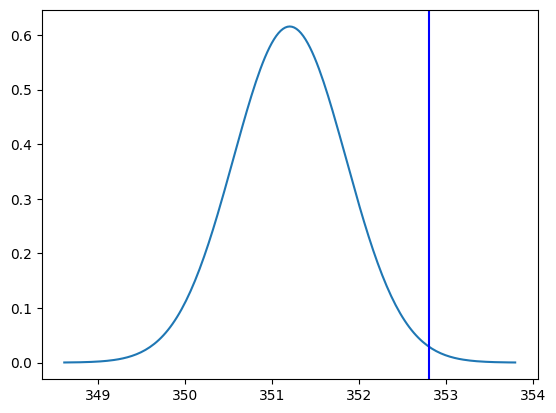

In [2]:
# Properties of the sample:
n = 40              # Sample size
mu = 351.2          # (Hypothetical) population mean
sigma = 4.1         # Population standard deviation (assumed to be known)
m_sample = 352.8    # Sample mean
stderr = sigma / math.sqrt(n)

# X-values
dist_x = np.linspace(mu - 4 * stderr, mu + 4 * stderr, num=201)
# Y-values for drawing the Gauss curve
dist_y = stats.norm.pdf(dist_x, mu, stderr)
# Plot the Gauss-curve
plt.plot(dist_x, dist_y)

# Fill the area left of x
# plt.fill_between(dist_x, 0, dist_y, where=(dist_x <= x), color='lightblue')
# Show the mean with an orange line
plt.axvline(m_sample, color="blue");

The testing procedure then runs as follows:

- **Step 1.** Formulate the hypotheses:

    - $H_0: \mu \leq 351.2$ (the amount of jam has not increased)
    - $H_1: \mu > 351.2$ (the amount of jam has increased)

- **Step 2.** Choose a significance level, e.g. $\alpha = 0.05$

- **Step 3.** Determine the value of the test statistic, in this case $\overline{x} = 352.8$

    *Remark:* in some textbooks, the test statistic is defined as the $z$-score of the sample mean, which is calculated as $z = (\overline{x} - \mu) / (\sigma / \sqrt{n})$

- **Step 4.** Determine the $p$-value and reject $H_0$ if $p < \alpha$.


In [6]:
alpha = 0.05 # Significance level chosen by the researcher
p = stats.norm.sf(m_sample, loc=mu, scale=sigma/np.sqrt(n))

print("p-value: %.5f" % p)
if(p < alpha):
    print("p < alpha: reject H0")
else:
    print("p > alpha: do not reject H0")

p-value: 0.00679
p < alpha: reject H0


An alternative method is to determine the *critical region*, i.e. the set of all values for the sample mean where $H_0$ may be rejected. The boundary of that area is called the *critical value* $g$. To the left of it you can't reject $H_0$ (acceptance region), to the right you can (critical region). The area of the acceptance region is $1 - \alpha$, the area of the critical region is $\alpha$.

In [7]:
# Critical value according to the formula:
#    g = mu + stats.norm.isf(alpha) * sigma / np.sqrt(n)
# Making use of the loc/scale parameters of isf:
g = stats.norm.isf(alpha, loc=mu, scale=sigma / np.sqrt(n))
print("Critical value g ≃ %.3f" % g)
if (m_sample < g):
    print("sample mean = %.3f < g = %.3f: do not reject H0" % (m_sample, g))
else:
    print("sample mean = %.3f > g = %.3f: reject H0" % (m_sample, g))

Critical value g ≃ 352.266
sample mean = 352.800 > g = 352.266: reject H0


A plot of this case:

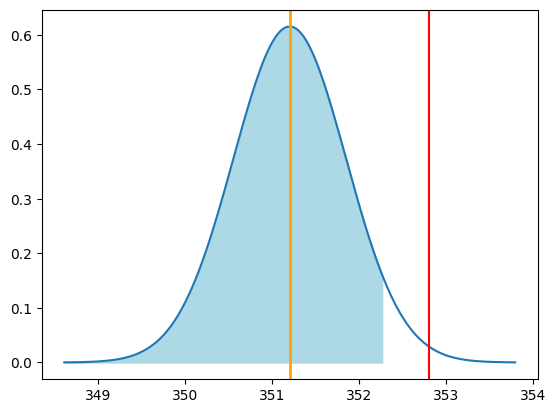

In [8]:
# Gauss-curve plot:
# X-values
dist_x = np.linspace(mu - 4 * sigma/np.sqrt(n), mu + 4 * sigma/np.sqrt(n), num=201)
# Y-values for the Gauss curve
dist_y = stats.norm.pdf(dist_x, mu, sigma/np.sqrt(n))
fig, dplot = plt.subplots(1, 1)
# Plot the Gauss-curve
dplot.plot(dist_x, dist_y)
# Show the hypothetical population mean with an orange line
dplot.axvline(mu, color="orange", lw=2)
# Show the sample mean with a red line
dplot.axvline(m_sample, color="red")
# Fill the acceptance area in light blue
dplot.fill_between(dist_x, 0, dist_y, where=dist_x <= g, color='lightblue');

- **Step 5** Draw conclusions.

    The $p$-value is smaller than the significance level $\alpha$, and the sample mean is in the critical region, so we reject the null hypothesis. This sample provides sufficient evidence to conclude that the machine fills the jars with more than 351.2 grams of jam.

### Example: the left-tailed $z$-test

Let's assume the mean quantity per jar is found to be 350.4g. In this case we have reasons to assume that the population mean is *lower* than the value we are testing against ($\mu$ = 351.2g). We can verify this with a *left-tailed* $z$-test.

**Step 1.** Formulate the hypotheses:

- $H_0: \mu \geq 351.2$ (the amount of jam has not decreased)
- $H_1: \mu < 351.2$ (the amount of jam has decreased)

**Step 2.** Choose significance level, e.g. $\alpha = 0.05$

**Step 3.** Calculate the test statistic: $\overline{x} = 350.4$

**Step 4.** Determine the $p$-value and reject $H_0$ if $p < \alpha$.

In [35]:
# Properties of the sample:
n = 40              # Sample size
mu = 351.2          # (Hypothetical) population mean
sigma = 4.1         # Population standard deviation (assumed to be known)
m_sample = 350.4    # Sample mean
alpha = 0.05        # Significance level (chosen by the researcher)

In [36]:
# Pay attention! Use cdf() instead of sf()! Why?
p = stats.norm.cdf(m_sample, loc=mu, scale=sigma/np.sqrt(n))

print("p-value: %.5f" % p)
if(p < alpha):
    print("p < a, reject H0")
else:
    print("p > a, do not reject H0")

p-value: 0.10859
p > a, do not reject H0


In this case, the critical value $g$ is left of the mean. On the right of $g$, you may not reject $H_0$ (acceptance region), on the left, you can (critical region).

In [37]:
# Critical value according to the formula in the lecture slides
# g = m0 - stats.norm.isf(a) * s / np.sqrt(n)
# Making use of the loc/scale parameters of isf:
g = stats.norm.isf(1-alpha, loc=mu, scale=(sigma / np.sqrt(n)))
print("Critical value g ≃ %.3f" % g)
if (m_sample > g):
    print("sample mean = %.3f > g = %.3f: do not reject H0" % (m_sample, g))
else:
    print("sample mean = %.3f < g = %.3f: reject H0" % (m_sample, g))

Critical value g ≃ 350.134
sample mean = 350.400 > g = 350.134: do not reject H0


A plot of this case:

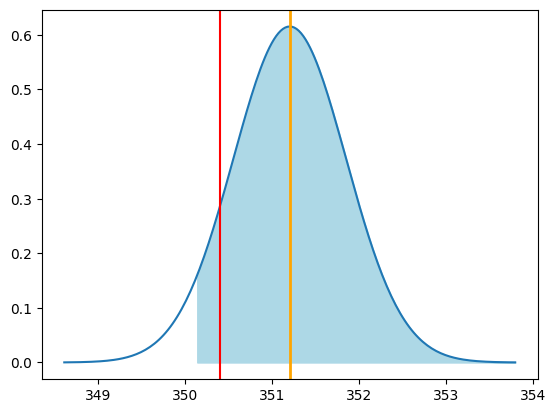

In [38]:
# Gauss-curve:
# X-values
dist_x = np.linspace(mu - 4 * sigma/np.sqrt(n), mu + 4 * sigma/np.sqrt(n), num=201)
# Y-values
dist_y = stats.norm.pdf(dist_x, mu, sigma/np.sqrt(n))
fig, dplot = plt.subplots(1, 1)
# Plot
dplot.plot(dist_x, dist_y)
# Hypothetical population mean in orange
dplot.axvline(mu, color="orange", lw=2)
# Sample mean in red
dplot.axvline(m_sample, color="red")
# Fill the acceptance region in light blue
dplot.fill_between(dist_x, 0, dist_y, where=dist_x >= g, color='lightblue');

- **Step 5** Draw conclusions.

    In this case, we see that the sample mean (the red line) still falls within the acceptance region (the area in light blue), so we cannot reject the null hypothesis. This is also confirmed by the $p$-value, which is greater than $\alpha$. With this result, there is no reason to assume the machine is not working correctly. In other words, the sample does not provide sufficient evidence to conclude that the machine is filling the jars with less than 351.2 grams of jam.

## The two-tailed $z$-test

When we don't want to test whether the population mean is either greater or lower than a hypothetical value, but only want to know if the sample mean is "close enough", we can use a two-tailed $z$-test.

**Step 1.** Formulate the hypotheses:

- $H_0: \mu  =  351.2$ (the amount of jam has not changed)
- $H_1: \mu \ne 351.2$ (the amount of jam has changed)

**Step 2.** Choose significance level, e.g. $\alpha = 0.05$

**Step 3.** Determine the test statistic. Assume the mean quantity per jar is found to be 351.4g.

$$\overline{x} = 351.4$$

**Step 4.** Calculate the $p$-value and reject $H_0$ if $p < \alpha/2$ (why do we divide by 2?).

In [39]:
# Properties of the sample:
n = 40              # Sample size
mu = 351.2          # (Hypothetical) population mean
sigma = 4.1         # Population standard deviation (assumed to be known)
m_sample = 351.4    # Sample mean
alpha = 0.05        # Significance level (chosen by the researcher)

In [40]:
p = stats.norm.sf(m_sample, loc=mu, scale=sigma/np.sqrt(n))
print("p-waarde: %.5f" % p)
if(p < alpha/2):
    print("p < alpha/2, reject H0")
else:
    print("p > alpha/2, do not reject H0")

p-waarde: 0.37885
p > alpha/2, do not reject H0


In this case, we have two critical values: $g_1$ on the left of the mean and $g_2$ on the right. The acceptance region still has area $1-\alpha$ and the critical region has area $\alpha$.

In [41]:
g1 = mu - stats.norm.isf(alpha/2) * sigma / np.sqrt(n)
g2 = mu + stats.norm.isf(alpha/2) * sigma / np.sqrt(n)

print("Acceptance region [g1, g2] ≃ [%.3f, %.3f]" % (g1,g2))
if (g1 < m_sample and m_sample < g2):
    print("Sample mean = %.3f is inside acceptance region: do not reject H0" % m_sample)
else:
    print("Sample mean = %.3f is outside acceptance region: reject H0" % m_sample)

Acceptance region [g1, g2] ≃ [349.929, 352.471]
Sample mean = 351.400 is inside acceptance region: do not reject H0


A plot of this case:

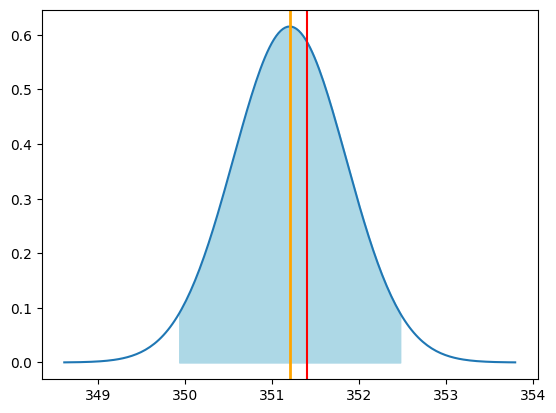

In [42]:
# Gauss-curve
# X-values
dist_x = np.linspace(mu - 4 * sigma/np.sqrt(n), mu + 4 * sigma/np.sqrt(n), num=201)
# Y-values
dist_y = stats.norm.pdf(dist_x, loc=mu, scale=sigma/np.sqrt(n))
# Plot
plt.plot(dist_x, dist_y)
# Hypothetical population mean in orange
plt.axvline(mu, color="orange", lw=2)
# Sample mean in red
plt.axvline(m_sample, color="red")
acc_x = np.linspace(g1, g2, num=101)
acc_y = stats.norm.pdf(acc_x, loc=mu, scale=sigma/np.sqrt(n))
# Fill the acceptance region in light blue
plt.fill_between(acc_x, 0, acc_y, color='lightblue');

**Step 5** Draw conclusions

The obtained sample mean turns out to be sufficiently probable. We cannot rule out a random sampling error. Or, in other words, we *cannot* reject the null hypothesis here. The sample does not provide sufficient evidence to conclude that the machine is not working correctly.

## Student's $t$-test

The $z$-test can only be used under specific conditions:

- The sample needs to be random  
- The sample size needs to be sufficiently large ($n \geq 30$)
- The test statistic needs to have a normal distribution  
- The standard deviation of the population, $\sigma$, is known

Sometimes these assumptions will not hold and in this case we can not use the $z$-test! If the variable is normally distributed, you can use Student's $t$-test.

The test was named after [William Sealy Gosset](https://en.wikipedia.org/wiki/William_Sealy_Gosset), who published results of his research under the pseudonym "Student". Gosset worked for the Guinness Brewery in Dublin, Ireland, and was interested in the problems of small samples - for example, the chemical properties of barley. He developed the $t$-test to work with small samples. Guinness did not want to reveal its trade secrets, so Gosset had to publish his work under a pseudonym.

### Example

In one course, a new textbook was used this school year. The old textbook received an average score of 5.2 out of 10. To know if the new textbook is more appreciated than the old one, the opinion of the 41 students who are redoing the course this school year is asked. Below are the scores of these 41 students:

```python
scores = [6, 3, 6, 7, 6, 10, 6, 8, 7, 9, 3, 6, 4, 6, 8, 9, 5, 4, 6, 4, 6, 8, 10, 5, 4, 6, 4, 6, 6, 4, 5, 7, 8, 7, 5, 4, 8, 4, 5, 10, 7]
```

Can we say that the score of the new textbook is significantly higher?

This is a *right-tailed* test, because we are testing whether the score of the new textbook is higher than the score of the old textbook. The testing procedure then runs as follows:

**Step 1.** Formulate the hypotheses:

- $H_0: \mu = 5.2$ (the score isn't higher)
- $H_1: \mu > 5.2$ (the score is higher)

**Step 2.** Choose significance level, e.g. $\alpha = 0.05$

**Step 3.** Calculate the test statistic $\overline{x}$

In [25]:
scores = [6, 3, 6, 7, 6, 10, 6, 8, 7, 9, 3, 6, 4, 6, 8, 9, 5, 4, 6, 4, 6, 8, 10, 5, 4, 6, 4, 6, 6, 4, 5, 7, 8, 7, 5, 4, 8, 4, 5, 10, 7]
n = len(scores)
mu = 5.2
s = np.std(scores, ddof = 1)  # the standard deviation of the population is unknown
stderr = s / math.sqrt(n)
m_sample = np.mean(scores)
alpha = 0.05

print(f"Sample mean: {m_sample}")
print(f"Standard error: {stderr}")

Sample mean: 6.146341463414634
Standard error: 0.29747099799147486


**Step 4.** Determine the $p$-value and do not reject $H_0$ if $p > \alpha$.

In [26]:
p = stats.t.sf(m_sample, loc = mu, scale = stderr, df = n - 1)
print(f"p-value: {p}")
if(p < alpha):
    print("p < alpha: reject H0")
else:
    print("p > alpha: do not reject H0")

p-value: 0.0014163864505844037
p < alpha: reject H0


Or calculate the critical value $g$ and do not reject $H_0$ if $\overline{x} > g$.

In [27]:
g = stats.t.isf(alpha, loc = mu, scale = stderr, df = n - 1)
print("Critical value g ≃ %.3f" % g)
if (m_sample < g):
    print("sample mean = %.3f < g = %.3f: do not reject H0" % (m_sample, g))
else:
    print("sample mean = %.3f > g = %.3f: reject H0" % (m_sample, g))


Critical value g ≃ 5.701
sample mean = 6.146 > g = 5.701: reject H0


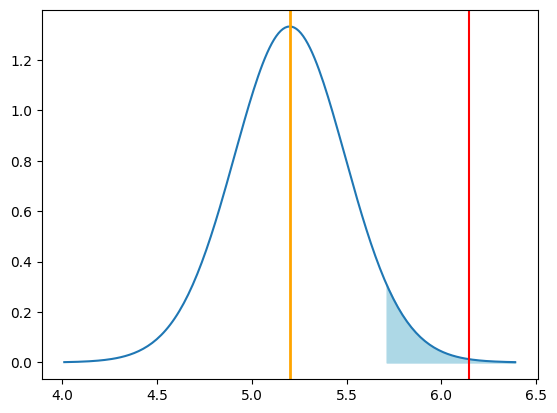

In [28]:
# Gauss-curve
# X-values
dist_x = np.linspace(mu - 4 * stderr, mu + 4 * stderr, num=201)
# Y-values
dist_y = stats.t.pdf(dist_x, loc=mu, scale=stderr, df=n-1)
# Plot
plt.plot(dist_x, dist_y)
# Hypothetical population mean in orange
plt.axvline(mu, color="orange", lw=2)
# Sample mean in red
plt.axvline(m_sample, color="red")
# Fill the acceptance region in light blue
plt.fill_between(dist_x, 0, dist_y, where=dist_x >= g, color='lightblue');

**Step 5** Draw conclusions.

There is sufficient evidence to reject $H_0$. Thus, there is sufficient evidence to conclude that the new textbook is more appreciated by the students.

### Use of the function `ttest_1samp`


SciPy provides a function `ttest_1samp()` that allows you to perform a *two-tailed* t-test on a collection of observations. It is used to compare the mean of a single sample to a given population mean. It helps determine whether the sample mean is significantly different from the population mean.

When to use ttest_1samp?
- You have one sample of data.
- You want to test if its mean significantly differs from a known or hypothesized population mean.
- The data is assumed to be normally distributed (or approximately normal for large samples).
- The standard deviation of the population is not known

### Example

A university claims that students spend an average of 20 hours per week studying. A researcher collects data from 15 students to test whether their average study time is different from 20 hours.

**Step 1.** Formulate the hypotheses:

- $H_0: \mu = 20$ (The average study time is 20 hours.)
- $H_1: \mu \ne 20$ (The average study time is not 20 hours.)

**Step 2.** Choose significance level, e.g. $\alpha = 0.05$

**Step 3.** Calculate the test statistic $\overline{x} = 19.93 $

**Step 4.** Determine the $p$-value and do not reject $H_0$ if $p > \alpha$.

In [43]:
study_times = [18,22,19,21,23,20,17,22,19,18,21,20,16,24,19]
alpha = 0.05
mu = 20

t_stat, p_val = stats.ttest_1samp(a=study_times, popmean=mu, alternative='less')
print("Sample mean        : %.3f" % np.mean(study_times))
print("t-score            : %.3f" % t_stat)
print(f"p-value           : {p_val}")

Sample mean        : 19.933
t-score            : -0.115
p-value           : 0.4551527949196003


**Step 5** Draw conclusions.

There is insufficient evidence to reject $H_0$. Thus, there is to reason to believe that the average study time is significantly different from 20.

## When to use the $z$-test and $t$-test?

There is no similar function as `ttest_1samp()` for the $z$-test. In practice, the $z$-test is rarely used because the conditions for its use are rarely met. In particular, the assumption that the population variance is known is not realistic. The $t$-test is more versatile and can be used in a wider range of situations.

As a conclusion:

**When to use the $z$-test?**

- in case of a large sample (no matter which distribution) or a small sample if the underlying distribution is the normal distribution

ánd

- if the variance or standard deviation of the population is known


**When to use the $t$-test?**

- if the underlying distribution is the normal distribution

ánd

- if the variance or standard deviation of the population is unknown

## Errors in Hypothesis Tests

- **Type I error** (false positive)  

    The null hypothesis is actually true and you reject it.  

    Example: A COVID test wrongly indicates a person is infected when they are actually healthy.

- **Type II error** (false negative)    

    You accept the null hypothesis and it was not true.  

    Example: A COVID test wrongly indicates a person is healthy when they are actually infected.

- P(type I error) = $\alpha$ (= significance level)  
- P(type II error) = $\beta$  

Calculating $\beta$ is not feasible (as you would need to know the true population parameter), but when you lower the value of $\alpha$ then $\beta$ will increase, and vice versa.

This is because when you lower $\alpha$, you are making it harder to reject the null hypothesis, which increases the chances of failing to reject a false null hypothesis (type II error). Conversely, when you increase $\alpha$, you are making it easier to reject the null hypothesis, which decreases the chances of failing to reject a false null hypothesis.

## Summary

### $z$-test for population mean

Prerequisites:

- The samples are independent and randomly selected.
- The distribution of the population is normal, or the sample size is large enough (n > 30).
- The population standard deviation ($\sigma$) is known.

As *test statistic*, the sample mean ($\bar{x}$), (or the $z$-score of the sample mean) is used.

Formulation of the null and alternative hypotheses:

|       | Left-tailed      | Right-tailed     | Two-tailed       |
| :---  | :---:            | :---:            | :---:            |
| $H_0$ | $\mu \geq \mu_0$ | $\mu \leq \mu_0$ | $\mu = \mu_0$    |
| $H_1$ | $\mu < \mu_0$    | $\mu > \mu_0$    | $\mu \neq \mu_0$ |

### $t$-test for population mean

Prerequisites:

- The samples are independent and randomly selected.
- The underlying population is normal.
- The population standard deviation ($\sigma$) is unknown.

As *test statistic*, the sample mean ($\bar{x}$), (or the $t$-score of the sample mean) is used.

The formulation of the null and alternative hypotheses is the same as in the $z$-test.

